In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('candy-data.csv')
df.head(5)
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   competitorname    85 non-null     object 
 1   chocolate         85 non-null     int64  
 2   fruity            85 non-null     int64  
 3   caramel           85 non-null     int64  
 4   peanutyalmondy    85 non-null     int64  
 5   nougat            85 non-null     int64  
 6   crispedricewafer  85 non-null     int64  
 7   hard              85 non-null     int64  
 8   bar               85 non-null     int64  
 9   pluribus          85 non-null     int64  
 10  sugarpercent      85 non-null     float64
 11  pricepercent      85 non-null     float64
 12  winpercent        85 non-null     float64
dtypes: float64(3), int64(9), object(1)
memory usage: 8.8+ KB


(85, 13)

In [3]:
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)

df.dropna(inplace=True)
df.shape

(85, 13)

In [4]:
from sklearn.model_selection import train_test_split
traing_set,test_set=train_test_split(df,test_size=0.2)


In [5]:
train_df=traing_set
test_df=test_set


In [6]:
x_train=train_df[['fruity','caramel','peanutyalmondy','nougat','hard','bar','pluribus','sugarpercent','pricepercent','winpercent']]
y_train=train_df['chocolate']
x_test=test_df[['fruity','caramel','peanutyalmondy','nougat','hard','bar','pluribus','sugarpercent','pricepercent','winpercent']]
y_test=test_df['chocolate']

In [7]:
df.head(5)

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


In [8]:
y_train.value_counts()


chocolate
0    36
1    32
Name: count, dtype: int64

## data exploration 

C:\Users\HP\AppData\Local\Temp\ipykernel_3528\125839381.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="chocolate",data=train_df,palette='Blues_d')


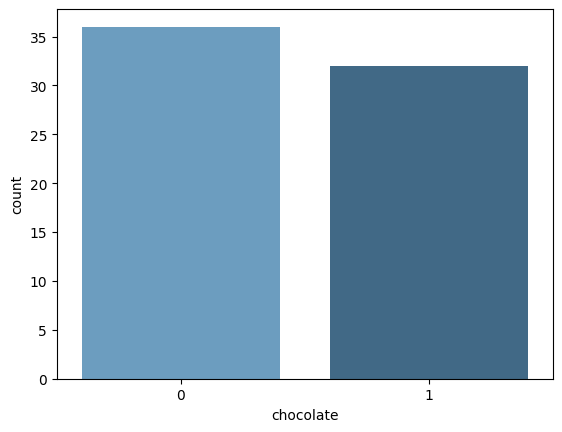

<Figure size 640x480 with 0 Axes>

In [9]:
sns.countplot(x="chocolate",data=train_df,palette='Blues_d')
plt.show()
plt.savefig('count_plot')

### model development  and peditcion 

In [10]:
from sklearn.linear_model import LogisticRegression 
logreg=LogisticRegression()
logreg.fit(x_train,y_train)
y_pred=logreg.predict(x_test)


In [11]:
from sklearn import metrics
cnf_matrix=metrics.confusion_matrix(y_test,y_pred)
cnf_matrix


array([[11,  1],
       [ 0,  5]])

In [12]:

print("Accuracy :",metrics.accuracy_score(y_test,y_pred))
print("Precision :",metrics.precision_score(y_test,y_pred))
print("Recall :",metrics.recall_score(y_test,y_pred))

Accuracy : 0.9411764705882353
Precision : 0.8333333333333334
Recall : 1.0
